# Level 3 - Task 1: Random Forest Classifier

## Objective

Build a Random Forest Classifier to predict customer churn using the Churn dataset.

### Goals
- Explore and preprocess the dataset
- Train a Random Forest classification model
- Tune hyperparameters using GridSearchCV
- Evaluate the model using classification metrics
- Perform cross-validation
- Analyze feature importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("churn-bigml-80.csv")

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (2666, 20)

Column Names:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

Data Types:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl 

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


### Observation

The dataset was checked for missing values. Any missing values identified will be handled during preprocessing before model training.

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State,2666,51,WV,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account length,2666.0,NaN,NaN,NaN,100.620405,39.563974,1.0,73.0,100.0,127.0,243.0
Area code,2666.0,NaN,NaN,NaN,437.43886,42.521018,408.0,408.0,415.0,510.0,510.0
International plan,2666,2,No,2396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Voice mail plan,2666,2,No,1933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number vmail messages,2666.0,NaN,NaN,NaN,8.021755,13.612277,0.0,0.0,0.0,19.0,50.0
Total day minutes,2666.0,NaN,NaN,NaN,179.48162,54.21035,0.0,143.4,179.95,215.9,350.8
Total day calls,2666.0,NaN,NaN,NaN,100.310203,19.988162,0.0,87.0,101.0,114.0,160.0
Total day charge,2666.0,NaN,NaN,NaN,30.512404,9.215733,0.0,24.38,30.59,36.7,59.64
Total eve minutes,2666.0,NaN,NaN,NaN,200.386159,50.951515,0.0,165.3,200.9,235.1,363.7


In [6]:
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
False    2278
True      388
Name: count, dtype: int64

Churn Percentage:
Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64


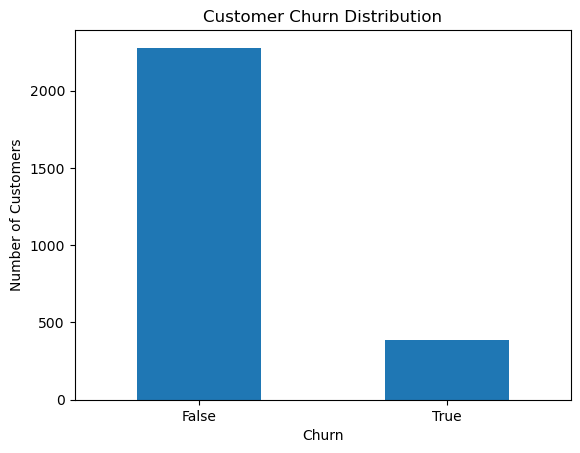

In [7]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

### Observation

The target variable shows the distribution of customers who stayed with the company and those who churned. This helps determine whether the dataset is balanced or imbalanced.

In [8]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2666, 19)
Target shape: (2666,)


In [9]:
categorical_features = [
    "State",
    "Area code",
    "International plan",
    "Voice mail plan"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['State', 'Area code', 'International plan', 'Voice mail plan']

Numerical Features:
['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


In [10]:
print("Total missing values:", df.isnull().sum().sum())

print("\nMissing values by column:")
print(df.isnull().sum())

Total missing values: 0

Missing values by column:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


### Missing Value Analysis

The dataset was checked for missing values. No missing values were found, so no additional missing-value imputation was required.

In [11]:
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn
False    2278
True      388
Name: count, dtype: int64

Churn Percentage:
Churn
False    85.45
True     14.55
Name: proportion, dtype: float64


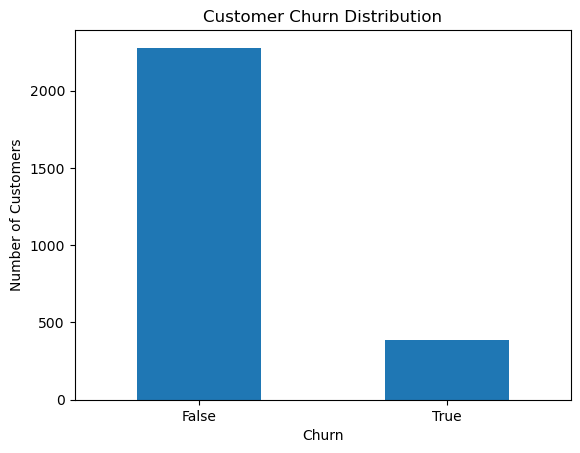

In [12]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2666, 19)
Target shape: (2666,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (2132, 19)
Testing set: (534, 19)


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [16]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model)
    ]
)

In [17]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=True)
recall = recall_score(y_test, y_pred, pos_label=True)
f1 = f1_score(y_test, y_pred, pos_label=True)

print("Initial Random Forest Performance")
print("----------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Initial Random Forest Performance
----------------------------------
Accuracy : 0.9438
Precision: 1.0000
Recall   : 0.6154
F1 Score : 0.7619


### Observation

The initial Random Forest model achieved an accuracy of 94.38% and an F1-score of 76.19% on the test set. The precision was 100%, indicating that the customers predicted as churners were correctly classified. However, the recall was 61.54%, showing that some actual churners were not detected by the model.

In [19]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

       False       0.94      1.00      0.97       456
        True       1.00      0.62      0.76        78

    accuracy                           0.94       534
   macro avg       0.97      0.81      0.87       534
weighted avg       0.95      0.94      0.94       534



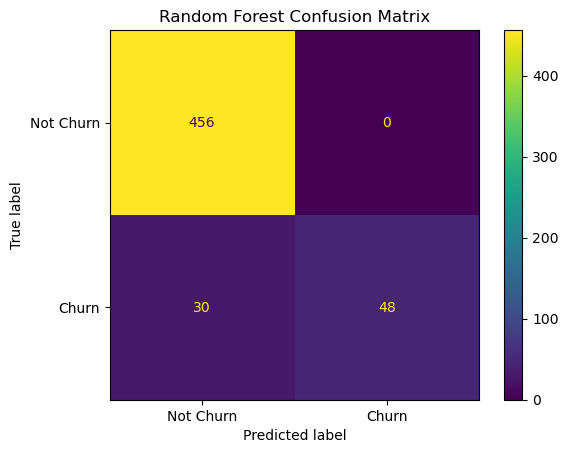

In [20]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [21]:
cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Cross-Validation F1 Scores:")
print(cv_scores)

print("\nMean Cross-Validation F1 Score:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

Cross-Validation F1 Scores:
[0.8        0.70967742 0.77862595 0.752      0.74193548]

Mean Cross-Validation F1 Score: 0.7564
Standard Deviation: 0.031


### Observation

Five-fold cross-validation produced F1-scores ranging from approximately 0.710 to 0.800, with a mean F1-score of 0.7564 and a standard deviation of 0.0310. The relatively small standard deviation indicates reasonably consistent performance across the validation folds.

In [22]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

In [23]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_leaf': [1, 2], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('categorical', ...)]"


In [24]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

Best Cross-Validation F1 Score:
0.7722


### Observation

GridSearchCV identified the following as the best hyperparameters:

- Number of trees: 200
- Maximum depth: 20
- Minimum samples split: 2
- Minimum samples leaf: 1

The best cross-validation F1-score was 0.7722.

In [25]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, pos_label=True)
recall_tuned = recall_score(y_test, y_pred_tuned, pos_label=True)
f1_tuned = f1_score(y_test, y_pred_tuned, pos_label=True)

print("Tuned Random Forest Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall   : {recall_tuned:.4f}")
print(f"F1 Score : {f1_tuned:.4f}")

Tuned Random Forest Performance
--------------------------------
Accuracy : 0.9419
Precision: 1.0000
Recall   : 0.6026
F1 Score : 0.7520


### Observation

The tuned model achieved a test accuracy of 94.19% and an F1-score of 75.20%. Although the tuned model's test-set F1-score was slightly lower than the initial model's 76.19%, its best cross-validation F1-score was 77.22%. This demonstrates that hyperparameter tuning improved the model's cross-validation performance, although the improvement did not directly translate to the held-out test set.

In [26]:
print("Classification Report - Tuned Random Forest")
print("---------------------------------------------")

print(classification_report(y_test, y_pred_tuned))

Classification Report - Tuned Random Forest
---------------------------------------------
              precision    recall  f1-score   support

       False       0.94      1.00      0.97       456
        True       1.00      0.60      0.75        78

    accuracy                           0.94       534
   macro avg       0.97      0.80      0.86       534
weighted avg       0.95      0.94      0.94       534



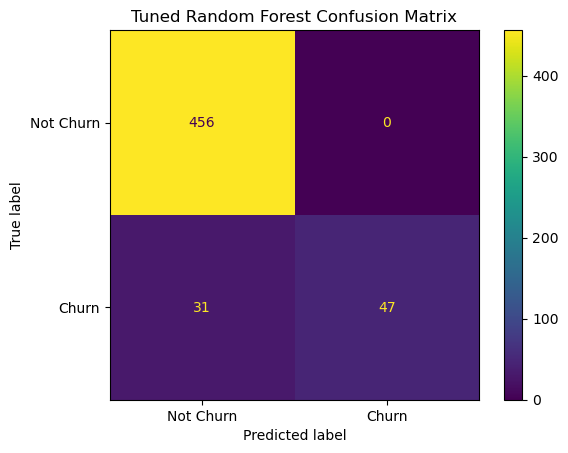

In [27]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

In [28]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Initial Model": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Tuned Model": [
        accuracy_tuned,
        precision_tuned,
        recall_tuned,
        f1_tuned
    ]
})

comparison

,Metric,Initial Model,Tuned Model
0,Accuracy,0.943820,0.941948
1,Precision,1.000000,1.000000
2,Recall,0.615385,0.602564
3,F1 Score,0.761905,0.752000


In [29]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = best_model.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
62,remainder__Total day charge,0.121459
60,remainder__Total day minutes,0.120067
72,remainder__Customer service calls,0.106047
65,remainder__Total eve charge,0.052494
63,remainder__Total eve minutes,0.051383
55,categorical__International plan_Yes,0.047574
69,remainder__Total intl minutes,0.042624
54,categorical__International plan_No,0.042559
71,remainder__Total intl charge,0.041636
70,remainder__Total intl calls,0.040497


### Observation

Feature importance analysis showed that Total day charge, Total day minutes, and Customer service calls were among the most influential features for predicting customer churn. International plan and evening usage-related features also contributed to the model's predictions.

These results suggest that customer usage patterns and interactions with customer service may provide useful signals for identifying customers at risk of churn.

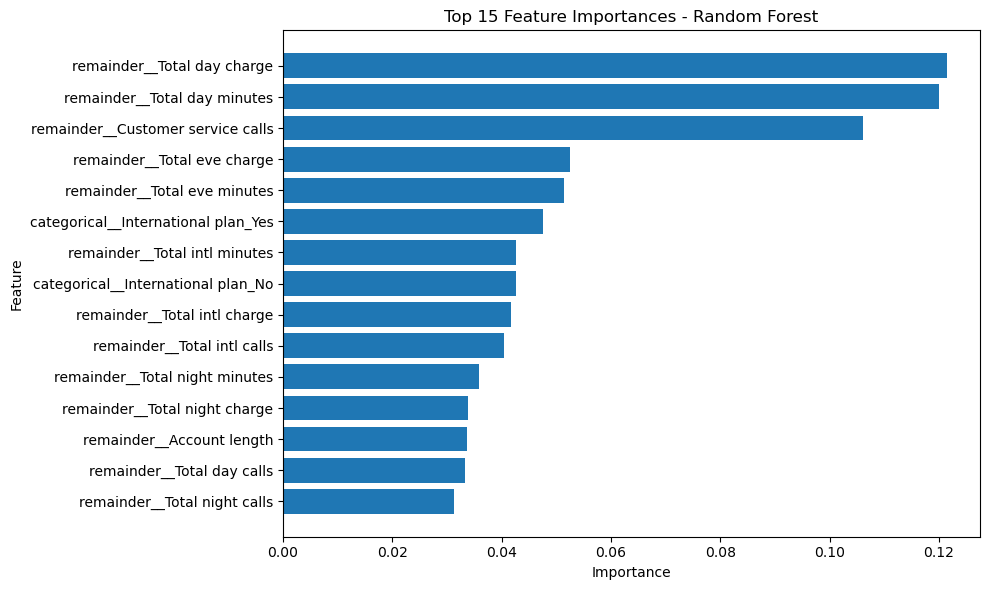

In [30]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()

In [31]:
print("FINAL RANDOM FOREST MODEL PERFORMANCE")
print("======================================")

print(f"Accuracy : {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall   : {recall_tuned:.4f}")
print(f"F1 Score : {f1_tuned:.4f}")

FINAL RANDOM FOREST MODEL PERFORMANCE
Accuracy : 0.9419
Precision: 1.0000
Recall   : 0.6026
F1 Score : 0.7520


# Conclusion

A Random Forest Classifier was successfully developed to predict customer churn using the customer churn dataset.

The data was explored and preprocessed using One-Hot Encoding for categorical variables. The dataset was divided into training and testing sets using an 80:20 stratified split.

The initial Random Forest model achieved 94.38% accuracy and a 76.19% F1-score on the test set. Five-fold cross-validation was performed to assess model stability.

Hyperparameter tuning using GridSearchCV identified an optimal configuration with 200 trees and a maximum tree depth of 20. The best cross-validation F1-score was 77.22%.

Feature importance analysis identified Total day charge, Total day minutes, and Customer service calls as some of the most important predictors of customer churn.

Overall, the Random Forest model performed well for customer churn classification and provided useful insights into the factors associated with customer churn.